Task#1

Dataset size: 60000
Train size: 48000
Test size: 12000
Image shape: torch.Size([1, 28, 28])
Data type: torch.float32


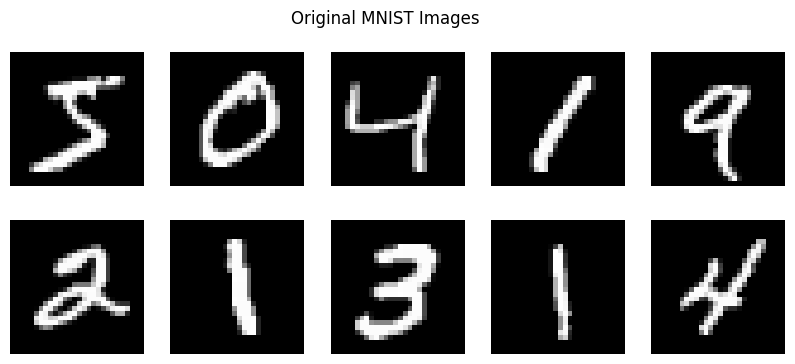

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.MNIST(root="C:\\Users\\alias\\Downloads\\Lab9_dataset", train=True, download=True, transform=transform)

torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Dataset size:", len(dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

sample_img, _ = dataset[0]
print("Image shape:", sample_img.shape)
print("Data type:", sample_img.dtype)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    img, _ = dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle("Original MNIST Images")
plt.show()

Task#2

In [ ]:
import torch
import torch.nn as nn

# Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),              # (1, 28, 28) -> (784)
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim) # latent space
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),              # значения в [0,1]
            nn.Unflatten(1, (1, 28, 28))
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

# Создаём модель
latent_dim = 32
model = Autoencoder(latent_dim)

# Вывод архитектуры
print(model)

# Подсчёт параметров
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_params)

# Размер латентного пространства
print("Latent dimension:", latent_dim)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
    (4): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)
Trainable parameters: 209968
Latent dimension: 32


Task#3

Reconstruction loss (before training): 0.23166632652282715


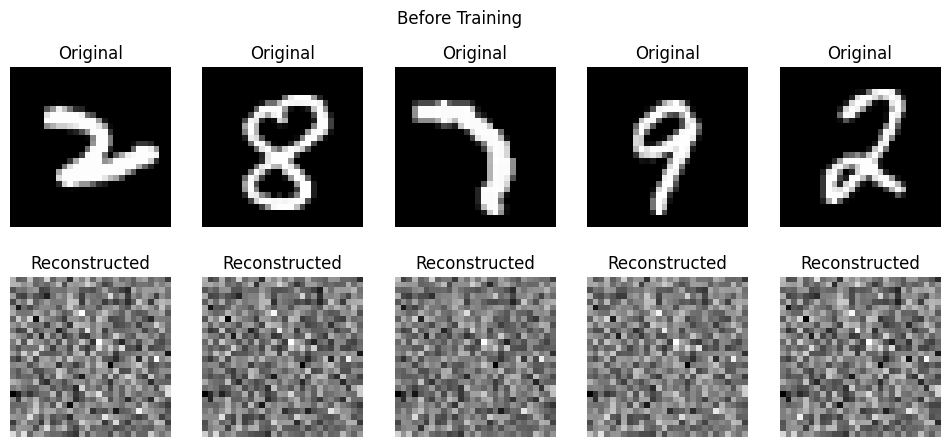

In [ ]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

# Функция потерь
criterion = nn.MSELoss()

# Берём один batch из test_loader
data_iter = iter(test_loader)
images, _ = next(data_iter)

# Прогон через НЕобученную модель
with torch.no_grad():
    reconstructions = model(images)

# Считаем loss
loss = criterion(reconstructions, images)
print("Reconstruction loss (before training):", loss.item())

# Визуализация
n = 5  # сколько картинок показать
fig, axes = plt.subplots(2, n, figsize=(12, 5))

for i in range(n):
    # Оригинал
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Реконструкция
    axes[1, i].imshow(reconstructions[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.suptitle("Before Training")
plt.show()

Task#4

Epoch [1/10] | Train Loss: 0.0085 | Test Loss: 0.0085
Epoch [2/10] | Train Loss: 0.0082 | Test Loss: 0.0082
Epoch [3/10] | Train Loss: 0.0080 | Test Loss: 0.0080
Epoch [4/10] | Train Loss: 0.0078 | Test Loss: 0.0078
Epoch [5/10] | Train Loss: 0.0076 | Test Loss: 0.0077
Epoch [6/10] | Train Loss: 0.0075 | Test Loss: 0.0076
Epoch [7/10] | Train Loss: 0.0074 | Test Loss: 0.0074
Epoch [8/10] | Train Loss: 0.0072 | Test Loss: 0.0074
Epoch [9/10] | Train Loss: 0.0071 | Test Loss: 0.0072
Epoch [10/10] | Train Loss: 0.0070 | Test Loss: 0.0072
Final Test Loss: 0.007170596031194671


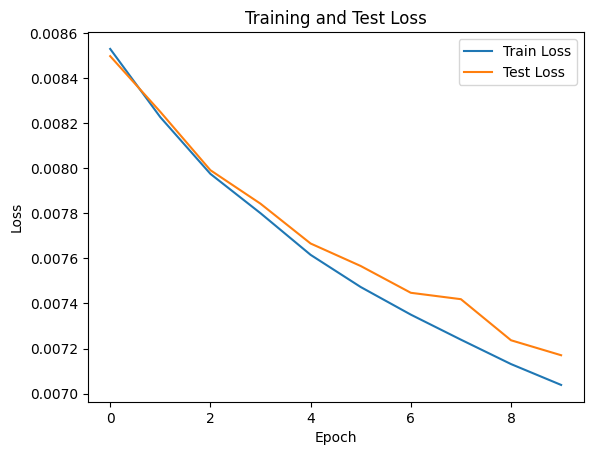

In [ ]:
import torch.optim as optim

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# GPU - используем
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 10

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    train_loss = 0
    
    for images, _ in train_loader:
        images = images.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, images)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # TEST
    model.eval()
    test_loss = 0
    
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            test_loss += loss.item()
    
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Финальный loss
print("Final Test Loss:", test_losses[-1])

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

Task#5

Average MSE (after training): 0.007418558156132349


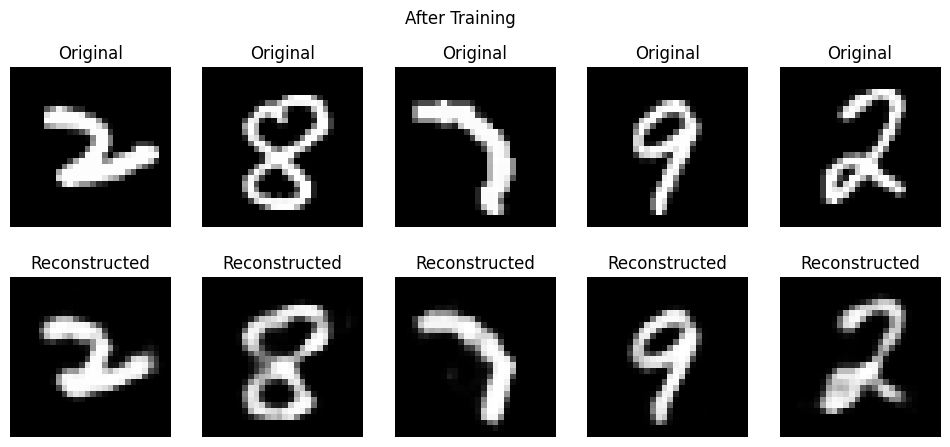

In [ ]:
criterion = nn.MSELoss()

model.eval()

# Берём batch
data_iter = iter(test_loader)
images, _ = next(data_iter)
images = images.to(device)

# Реконструкция ПОСЛЕ обучения
with torch.no_grad():
    reconstructions = model(images)

# MSE для каждого изображения
mse_list = []

for i in range(len(images)):
    mse = criterion(reconstructions[i], images[i]).item()
    mse_list.append(mse)

avg_mse = sum(mse_list) / len(mse_list)

print("Average MSE (after training):", avg_mse)

# Визуализация
n = 5
fig, axes = plt.subplots(2, n, figsize=(12, 5))

for i in range(n):
    # Оригинал
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Реконструкция
    axes[1, i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.suptitle("After Training")
plt.show()

Task#6

Latent vector shape: torch.Size([12000, 32])


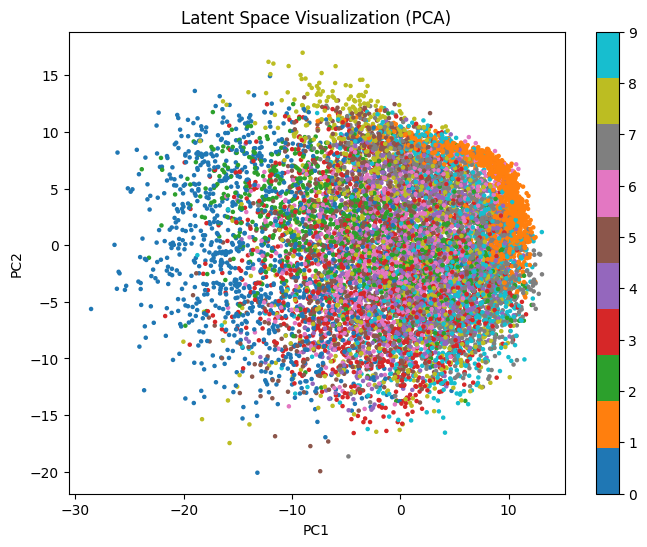

In [ ]:
from sklearn.decomposition import PCA

model.eval()

# Собираем латентные векторы
latent_vectors = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        z = model.encoder(images)  # получаем latent vectors
        
        latent_vectors.append(z.cpu())
        labels_list.append(labels)

# Объединяем
latent_vectors = torch.cat(latent_vectors, dim=0)
labels_list = torch.cat(labels_list, dim=0)

print("Latent vector shape:", latent_vectors.shape)

# PCA до 2D 
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels_list, cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("Latent Space Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Task#7

In [ ]:
def train_autoencoder(latent_dim, epochs=10):
    model = Autoencoder(latent_dim).to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss = 0
        
        for images, _ in train_loader:
            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # TEST
        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                outputs = model(images)
                loss = criterion(outputs, images)
                test_loss += loss.item()
        
        test_loss /= len(test_loader)
        test_losses.append(test_loss)
    
    return model, train_losses, test_losses

In [9]:
latent_dims = [8, 32, 64]
results = {}

for dim in latent_dims:
    print(f"Training model with latent_dim = {dim}")
    model_trained, train_l, test_l = train_autoencoder(dim, epochs=10)
    
    results[dim] = {
        "model": model_trained,
        "train_loss": train_l,
        "test_loss": test_l
    }

Training model with latent_dim = 8
Training model with latent_dim = 32
Training model with latent_dim = 64


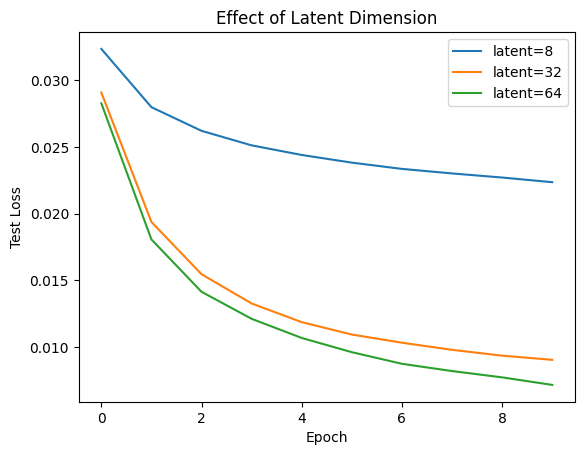

In [10]:
for dim in latent_dims:
    plt.plot(results[dim]["test_loss"], label=f"latent={dim}")

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Effect of Latent Dimension")
plt.legend()
plt.show()

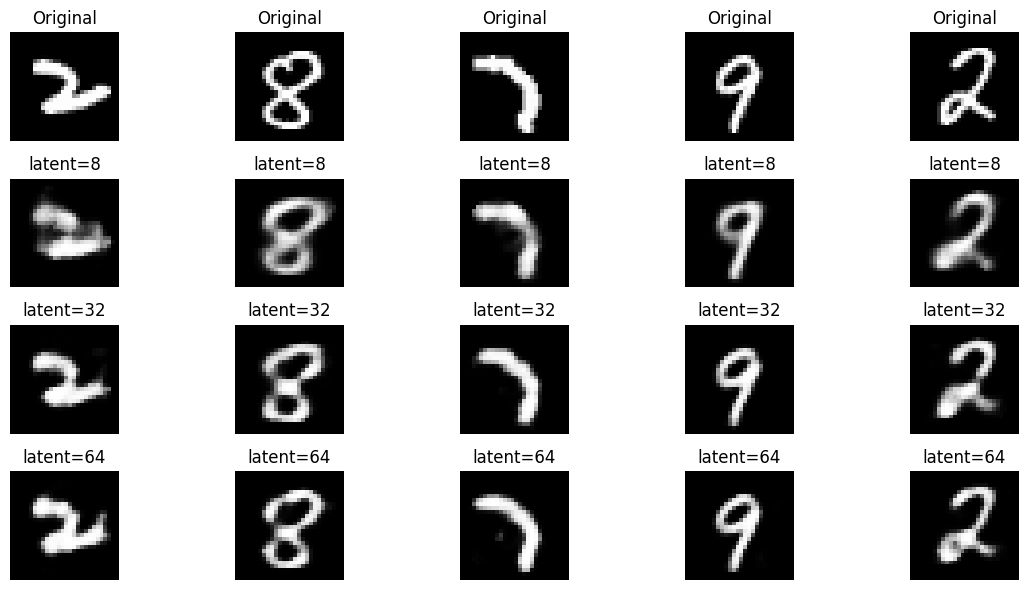

In [11]:
data_iter = iter(test_loader)
images, _ = next(data_iter)
images = images.to(device)

n = 5
fig, axes = plt.subplots(len(latent_dims)+1, n, figsize=(12, 6))

# оригинал
for i in range(n):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

# реконструкции
for row, dim in enumerate(latent_dims, start=1):
    model = results[dim]["model"]
    model.eval()
    
    with torch.no_grad():
        recon = model(images)
    
    for i in range(n):
        axes[row, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
        axes[row, i].set_title(f"latent={dim}")
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()

Task#8

In [12]:
def add_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

In [ ]:
model_denoise = Autoencoder(latent_dim=32).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_denoise.parameters(), lr=0.001)

epochs = 10

train_losses_dn = []
test_losses_dn = []

for epoch in range(epochs):
    # TRAIN 
    model_denoise.train()
    train_loss = 0
    
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images)
        
        optimizer.zero_grad()
        
        outputs = model_denoise(noisy_images)
        loss = criterion(outputs, images)  # сравниваем с ЧИСТЫМИ
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses_dn.append(train_loss)
    
    # TEST
    model_denoise.eval()
    test_loss = 0
    
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy_images = add_noise(images)
            
            outputs = model_denoise(noisy_images)
            loss = criterion(outputs, images)
            test_loss += loss.item()
    
    test_loss /= len(test_loader)
    test_losses_dn.append(test_loss)
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")

Epoch 1: Train Loss=0.0578, Test Loss=0.0357
Epoch 2: Train Loss=0.0298, Test Loss=0.0259
Epoch 3: Train Loss=0.0236, Test Loss=0.0218
Epoch 4: Train Loss=0.0202, Test Loss=0.0189
Epoch 5: Train Loss=0.0180, Test Loss=0.0174
Epoch 6: Train Loss=0.0168, Test Loss=0.0163
Epoch 7: Train Loss=0.0159, Test Loss=0.0154
Epoch 8: Train Loss=0.0150, Test Loss=0.0147
Epoch 9: Train Loss=0.0144, Test Loss=0.0143
Epoch 10: Train Loss=0.0139, Test Loss=0.0137


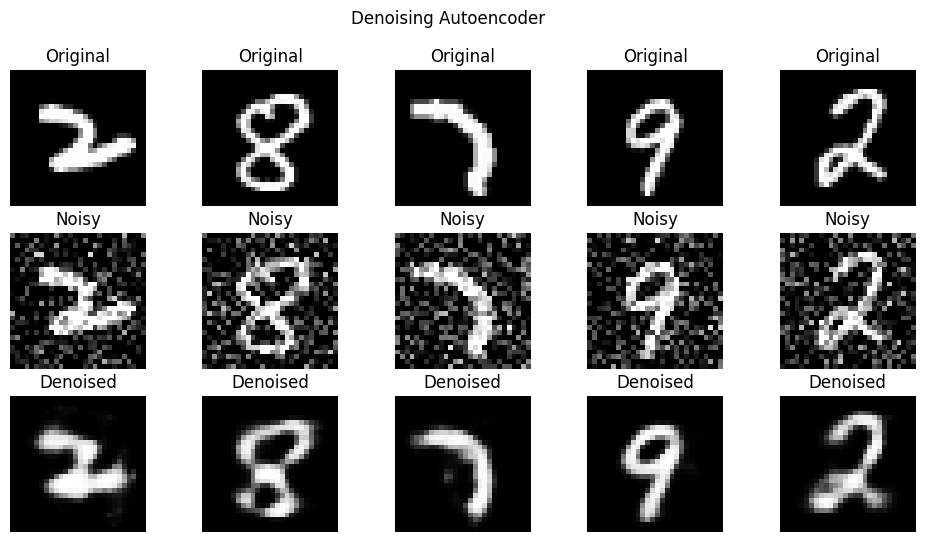

In [14]:
model_denoise.eval()

data_iter = iter(test_loader)
images, _ = next(data_iter)
images = images.to(device)

noisy_images = add_noise(images)

with torch.no_grad():
    denoised = model_denoise(noisy_images)

n = 5
fig, axes = plt.subplots(3, n, figsize=(12, 6))

for i in range(n):
    # Оригинал
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Шум
    axes[1, i].imshow(noisy_images[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy")
    axes[1, i].axis('off')
    
    # Восстановление
    axes[2, i].imshow(denoised[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title("Denoised")
    axes[2, i].axis('off')

plt.suptitle("Denoising Autoencoder")
plt.show()

Task#9

In [15]:
from torch.utils.data import Subset

target_class = 0

# индексы только для "0"
train_indices = [i for i, (_, label) in enumerate(train_dataset) if label == target_class]
test_indices_same = [i for i, (_, label) in enumerate(test_dataset) if label == target_class]
test_indices_diff = [i for i, (_, label) in enumerate(test_dataset) if label != target_class]

train_subset = Subset(train_dataset, train_indices)
test_same = Subset(test_dataset, test_indices_same)
test_diff = Subset(test_dataset, test_indices_diff)

train_loader_ano = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader_same = DataLoader(test_same, batch_size=128, shuffle=False)
test_loader_diff = DataLoader(test_diff, batch_size=128, shuffle=False)

In [16]:
model_ano = Autoencoder(latent_dim=32).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ano.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model_ano.train()
    total_loss = 0
    
    for images, _ in train_loader_ano:
        images = images.to(device)
        
        optimizer.zero_grad()
        outputs = model_ano(images)
        loss = criterion(outputs, images)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader_ano):.4f}")

Epoch 1, Loss: 0.1157
Epoch 2, Loss: 0.0589
Epoch 3, Loss: 0.0471
Epoch 4, Loss: 0.0391
Epoch 5, Loss: 0.0343
Epoch 6, Loss: 0.0313
Epoch 7, Loss: 0.0294
Epoch 8, Loss: 0.0266
Epoch 9, Loss: 0.0237
Epoch 10, Loss: 0.0217


In [17]:
def compute_errors(loader):
    errors = []
    
    model_ano.eval()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model_ano(images)
            
            loss = torch.mean((outputs - images) ** 2, dim=[1,2,3])
            errors.extend(loss.cpu().numpy())
    
    return errors

errors_same = compute_errors(test_loader_same)  # "0"
errors_diff = compute_errors(test_loader_diff)  # другие цифры

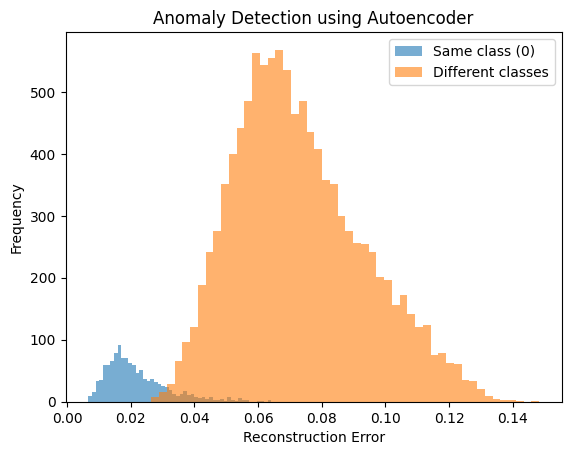

In [18]:
import matplotlib.pyplot as plt

plt.hist(errors_same, bins=50, alpha=0.6, label="Same class (0)")
plt.hist(errors_diff, bins=50, alpha=0.6, label="Different classes")

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Anomaly Detection using Autoencoder")
plt.legend()
plt.show()